In [12]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (2).zip


In [15]:
import zipfile

with zipfile.ZipFile('archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall()

In [16]:
import os
os.listdir()

['.config',
 'SuperMarket Analysis.csv',
 'archive (2).zip',
 'archive.zip',
 'archive (1).zip',
 'sample_data']

In [17]:
import pandas as pd

df = pd.read_csv('SuperMarket Analysis.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

In [20]:
X = df[['month','day']]
y = df['Sales']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
pred = model.predict(X_test)

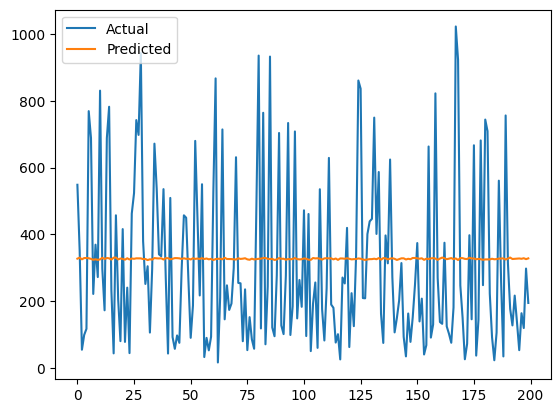

In [24]:
import matplotlib.pyplot as plt
plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()

This model predicts sales using date-based features like month and day. The predicted values are relatively stable compared to actual values, indicating that a simple linear regression captures general trends but may not model complex variations in sales.